# Avance 2 · Integración con la API de Yelp
### Proyecto Integrador M1 · *Conociendo al cliente 360°*
**Autor:** Tomás Babot · **Ciudad analizada:** Chicago

---

## Objetivo
Sumar información externa a la base de clientes: qué restaurantes hay en Chicago, cómo están calificados, qué precio tienen y qué tipo de cocina ofrecen. Así comparamos lo que piden los clientes (demanda) con lo que ofrece la ciudad (oferta).

## Pasos
1. Conectarse a la API de Yelp y extraer los negocios de Chicago.
2. Pasar la respuesta (JSON) a una tabla, guardarla en CSV y revisar su calidad.
3. Explorar los datos de Yelp.
4. Integrar Yelp con los clientes de Chicago del Avance #1 y guardar la base unificada en CSV.

## Cómo ejecutarlo
Se ejecuta de arriba hacia abajo. Lee y guarda CSV en la carpeta `data/`. La clave de la API no se escribe en el código: se guarda en un archivo `.env`, en la carpeta principal del repositorio, que no se sube a GitHub (ver la sección 1).

## 1. Preparar el entorno

Importamos las librerías y cargamos la clave de Yelp desde el archivo `.env`.

**¿Por qué un archivo `.env`?** La clave de una API es como una contraseña: si se publica, cualquiera puede usarla a nuestro nombre. Por eso no la escribimos en el código. La guardamos en un archivo `.env` que queda solo en nuestra computadora, y el archivo `.gitignore` le indica a git que no lo suba a GitHub. Para que otra persona sepa cómo configurarlo, el repositorio incluye `.env.example`, un modelo sin la clave.

**Para correr la consulta en vivo:**
1. Copiar `.env.example` con el nombre `.env`.
2. Pegar la clave de Yelp después de `YELP_API_KEY=`.
3. Instalar la librería que lee ese archivo: `pip install python-dotenv`.

`load_dotenv` lee el `.env` y carga la clave como variable de entorno; después `os.getenv('YELP_API_KEY')` la toma desde ahí. Si no hay `.env` o la clave está vacía, el notebook usa la descarga guardada en `data/`, así que corre igual.

In [1]:
import os
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv('../.env')   # lee la clave de Yelp del archivo .env (que no se sube a GitHub)

sns.set_theme(style='whitegrid')
plt.rcParams['text.parse_math'] = False   # para que el símbolo $ (precios) no se lea como una fórmula
pd.set_option('display.max_columns', None)

RUTA_DATA = Path('../data')

## 2. Conectarse a la API de Yelp y extraer los datos

Consultamos el endpoint `https://api.yelp.com/v3/businesses/search` con estos parámetros:

| Parámetro | Valor | Para qué sirve |
|---|---|---|
| `term` | `restaurants` | Qué tipo de negocio buscamos |
| `location` | `Chicago` | Ciudad elegida en el Avance #1 |
| `limit` | 50 | Máximo de resultados por página que permite Yelp |
| `offset` | 0, 50, 100... | Desde qué resultado empieza cada página |

La autenticación usa un token en el encabezado `Authorization: Bearer <clave>`. Como Yelp entrega de a 50 resultados, la función `descargar_negocios` pide una página por vez y junta todos los negocios en una lista.

In [2]:
def descargar_negocios(ciudad, api_key, cantidad=240):
    url = 'https://api.yelp.com/v3/businesses/search'
    headers = {'Authorization': f'Bearer {api_key}'}

    negocios = []
    for offset in range(0, cantidad, 50):          # offset = 0, 50, 100, 150, 200
        params = {'term': 'restaurants', 'location': ciudad,
                  'limit': min(50, cantidad - offset), 'offset': offset}
        respuesta = requests.get(url, params=params, headers=headers)
        print(f'Página desde el resultado {offset}: código de respuesta {respuesta.status_code}')   # 200 = OK
        pagina = respuesta.json()
        negocios.extend(pagina['businesses'])      # sumamos los negocios de esta página

    return {'businesses': negocios, 'total': pagina['total']}

Yelp responde con un JSON anidado: cada negocio es un diccionario con listas (las categorías) y otros diccionarios (ubicación, coordenadas). Así se ve uno, recortado:

```json
{
  "id": "qjnpkS8yZO8xcyEIy5OU9A",
  "name": "Girl & The Goat",
  "rating": 4.4,
  "review_count": 10749,
  "price": "$$$",
  "categories": [{"alias": "newamerican", "title": "New American"},
                 {"alias": "bars", "title": "Bars"}],
  "location": {"city": "Chicago", "zip_code": "60607"},
  "coordinates": {"latitude": 41.884, "longitude": -87.648},
  "transactions": ["delivery"]
}
```

Una tabla no puede guardar listas ni diccionarios en una celda, así que hay que aplanar el JSON. La celda siguiente:
1. Aplana los diccionarios con `pd.json_normalize` (`location.city`, `coordinates.latitude`...).
2. Elige y renombra las columnas que nos interesan.
3. Escribe las categorías como texto separado por comas (`Steakhouses, Wine Bars`).
4. Guarda el resultado en `data/yelp_restaurantes_chicago.csv`.

**Modo de ejecución:**
- Los 240 restaurantes del análisis se descargaron de la API el 24/09/2026 con esta misma consulta y están guardados en el CSV. Usamos siempre esa descarga para que los resultados no cambien cuando Yelp actualiza su ranking.
- Si el archivo `.env` tiene la clave (`YELP_API_KEY`), la celda vuelve a consultar la API en vivo y muestra el código de respuesta (200 = conexión correcta). Con `ACTUALIZAR_CSV = True` reemplaza la descarga guardada por la nueva.
- Si no hay clave, se lee el CSV guardado, así que el notebook corre sin clave ni conexión.

In [3]:
CIUDAD = 'Chicago'
API_KEY = os.getenv('YELP_API_KEY')        # la clave viene del archivo .env (cargado en la sección 1), no del código
RUTA_YELP = RUTA_DATA / 'yelp_restaurantes_chicago.csv'
ACTUALIZAR_CSV = False                      # True = reemplazar la descarga guardada por la nueva

if API_KEY:
    # 1) pedimos los datos a la API
    data = descargar_negocios(CIUDAD, API_KEY)
    print(f"Consulta en vivo: {len(data['businesses'])} negocios (Yelp registra {data['total']:,} en total)")

    # 2) aplanamos el JSON y nos quedamos con las columnas útiles
    crudo = pd.json_normalize(data['businesses'])
    df_vivo = crudo[['id', 'name', 'rating', 'review_count', 'price', 'location.city', 'location.zip_code',
                     'coordinates.latitude', 'coordinates.longitude']].copy()
    df_vivo.columns = ['id', 'nombre', 'rating', 'review_count', 'precio', 'ciudad', 'codigo_postal', 'latitud', 'longitud']

    # 3) las categorías (lista) y las transacciones pasan a texto / verdadero-falso
    df_vivo['categorias'] = crudo['categories'].apply(lambda lista: ', '.join([c['title'] for c in lista]))
    df_vivo['aliases'] = crudo['categories'].apply(lambda lista: ', '.join([c['alias'] for c in lista]))
    df_vivo['hace_delivery'] = crudo['transactions'].apply(lambda lista: 'delivery' in lista)
    df_vivo['esta_cerrado'] = crudo['is_closed']
    display(df_vivo.head())

    # 4) guardamos la tabla en CSV solo si lo pedimos
    if ACTUALIZAR_CSV:
        df_vivo.to_csv(RUTA_YELP, index=False)
        print('CSV actualizado:', RUTA_YELP)
    else:
        print('Conexión verificada. El análisis sigue con la descarga guardada del 24/09/2026.')
else:
    print('Sin YELP_API_KEY: se lee el CSV guardado con la descarga real de la API del 24/09/2026')

df_yelp = pd.read_csv(RUTA_YELP)
print(f'{df_yelp.shape[0]} restaurantes x {df_yelp.shape[1]} columnas')
df_yelp.head()

Página desde el resultado 0: código de respuesta 200


Página desde el resultado 50: código de respuesta 200


Página desde el resultado 100: código de respuesta 200


Página desde el resultado 150: código de respuesta 200


Página desde el resultado 200: código de respuesta 200
Consulta en vivo: 240 negocios (Yelp registra 7,900 en total)


,id,nombre,rating,review_count,precio,ciudad,codigo_postal,latitud,longitud,categorias,aliases,hace_delivery,esta_cerrado
0,qjnpkS8yZO8xcyEIy5OU9A,Girl & The Goat,4.4,10752,$$$,Chicago,60607,41.884193,-87.647946,"New American, Bars, Bakeries","newamerican, bars, bakeries",True,False
1,boE4Ahsssqic7o5wQLI04w,The Purple Pig,4.3,9061,$$$,Chicago,60611,41.890694,-87.624782,"Tapas/Small Plates, Mediterranean, New American","tapasmallplates, mediterranean, newamerican",True,False
2,8N3GMu-AhVvJMzQifkNemg,Crying Tiger,4.3,292,NaN,Chicago,60654,41.889903,-87.629899,Thai,thai,True,False
3,gzhkdb6YoiFm5s3vriG1AA,Gretel,4.5,484,$$,Chicago,60647,41.917275,-87.698577,"Cocktail Bars, New American, Speakeasies","cocktailbars, newamerican, speakeasies",True,False
4,GZsrGq6H8CQ4YlGtE_Bm0Q,Ciccio Mio,4.7,672,$$$,Chicago,60654,41.889265,-87.635215,Italian,italian,True,False


Conexión verificada. El análisis sigue con la descarga guardada del 24/09/2026.
240 restaurantes x 13 columnas


,id,nombre,rating,review_count,precio,ciudad,codigo_postal,latitud,longitud,categorias,aliases,hace_delivery,esta_cerrado
0,qjnpkS8yZO8xcyEIy5OU9A,Girl & The Goat,4.4,10749,$$$,Chicago,60607,41.884193,-87.647946,"New American, Bars, Bakeries","newamerican, bars, bakeries",True,False
1,boE4Ahsssqic7o5wQLI04w,The Purple Pig,4.3,9056,$$$,Chicago,60611,41.890694,-87.624782,"Tapas/Small Plates, Mediterranean, New American","tapasmallplates, mediterranean, newamerican",True,False
2,gzhkdb6YoiFm5s3vriG1AA,Gretel,4.5,483,$$,Chicago,60647,41.917275,-87.698577,"Cocktail Bars, New American, Speakeasies","cocktailbars, newamerican, speakeasies",True,False
3,8N3GMu-AhVvJMzQifkNemg,Crying Tiger,4.3,288,NaN,Chicago,60654,41.889903,-87.629899,Thai,thai,True,False
4,GZsrGq6H8CQ4YlGtE_Bm0Q,Ciccio Mio,4.7,672,$$$,Chicago,60654,41.889265,-87.635215,Italian,italian,True,False


## 3. Qué contiene la tabla de Yelp

| Columna | Significado |
|---|---|
| `id`, `nombre` | Identificador y nombre del restaurante |
| `rating` | Calificación promedio de los usuarios (de 1 a 5) |
| `review_count` | Cantidad de reseñas |
| `precio` | Rango de precio: `$` (económico) a `$$$$` (caro). Puede faltar |
| `ciudad`, `codigo_postal`, `latitud`, `longitud` | Ubicación |
| `categorias` | Tipo de cocina o negocio, en texto (`Steakhouses, Wine Bars`) |
| `aliases` | Lo mismo pero con los códigos internos de Yelp (`steak, wine_bars`) |
| `hace_delivery`, `esta_cerrado` | Verdadero / falso |

## 4. Control de calidad de los datos de Yelp

Revisamos nulos, duplicados y valores imposibles, igual que con los clientes, antes de cruzar las dos fuentes.

In [4]:
print('Nulos por columna:')
df_yelp.isnull().sum()

Nulos por columna:


id                0
nombre            0
rating            0
review_count      0
precio           96
ciudad            0
codigo_postal     0
latitud           0
longitud          0
categorias        0
aliases           0
hace_delivery     0
esta_cerrado      0
dtype: int64

In [5]:
print('Duplicados por id de negocio:', df_yelp['id'].duplicated().sum())
print('Rating fuera de 1-5:', (~df_yelp['rating'].between(1, 5)).sum())
print('Reseñas negativas:', (df_yelp['review_count'] < 0).sum())
print('Negocios cerrados:', df_yelp['esta_cerrado'].sum())

Duplicados por id de negocio: 0
Rating fuera de 1-5: 0
Reseñas negativas: 0
Negocios cerrados: 0


In [6]:
# Ciudades que figuran en los resultados
df_yelp['ciudad'].value_counts()

ciudad
Chicago            238
Harwood Heights      1
Lincoln Park         1
Name: count, dtype: int64

**Interpretación:**
- Los 240 negocios tienen `id` único, ratings válidos (entre 1 y 5), ninguna cantidad de reseñas negativa y ninguno está cerrado.
- El único faltante es `precio`: 96 negocios (40%) no lo informan. Los pasamos a `'Sin dato'` para no perderlos en los gráficos.
- 238 negocios son de Chicago y 2 de zonas vecinas (Harwood Heights y Lincoln Park). Salieron de la búsqueda de Chicago, así que los conservamos.

In [7]:
# Precio faltante -> categoría explícita (así los gráficos no ocultan estos restaurantes)
df_yelp['precio'] = df_yelp['precio'].fillna('Sin dato')

ORDEN_PRECIO = ['$', '$$', '$$$', '$$$$', 'Sin dato']
df_yelp['precio'].value_counts().reindex(ORDEN_PRECIO)

precio
$            1
$$          93
$$$         38
$$$$        12
Sin dato    96
Name: count, dtype: int64

## 5. Explorar la oferta de Chicago

### 5.1 Calificaciones y reseñas

In [8]:
df_yelp[['rating', 'review_count']].describe().round(2)

,rating,review_count
count,240.00,240.00
mean,4.38,671.81
std,0.26,1347.76
min,3.70,3.00
25%,4.20,84.25
50%,4.40,233.50
75%,4.50,662.00
max,5.00,10749.00


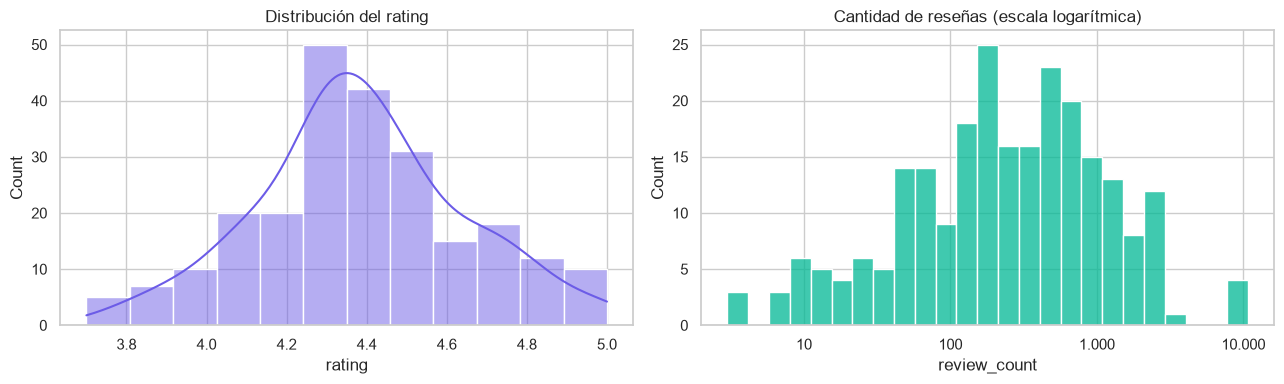

In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_yelp['rating'], bins=12, kde=True, ax=ejes[0], color='#6c5ce7')
ejes[0].set_title('Distribución del rating')

sns.histplot(df_yelp['review_count'], bins=25, log_scale=True, ax=ejes[1], color='#00b894')
ejes[1].set_title('Cantidad de reseñas (escala logarítmica)')
ejes[1].set_xticks([10, 100, 1000, 10000], ['10', '100', '1.000', '10.000'])   # etiquetas legibles en escala logarítmica

plt.tight_layout()
plt.show()

**Interpretación:**
- Las calificaciones son altas y parejas: media de 4,38, mediana de 4,40, entre 3,7 y 5,0. El 36% tiene 4,5 o más. Con tan poca variación, el rating diferencia poco a los restaurantes.
- Las reseñas son muy asimétricas (asimetría 5,2): mediana de 234 y media de 672, con un puñado de locales con miles (el que más, 10.749). Por eso se grafican en escala logarítmica.

### 5.2 Precio y tipo de cocina

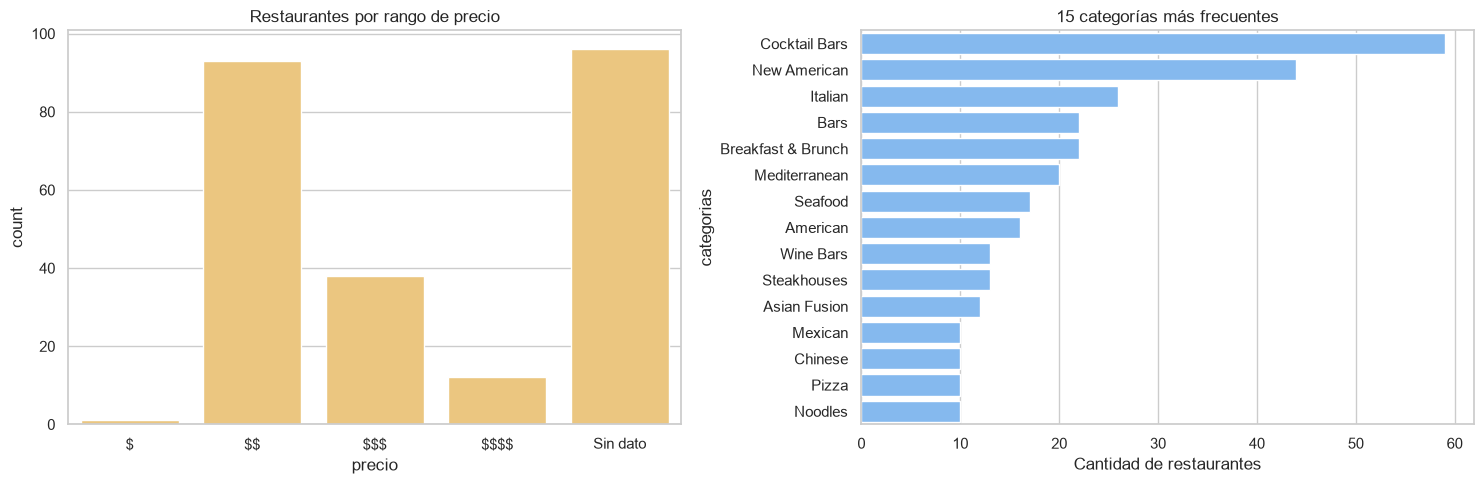

In [10]:
# Cada restaurante tiene varias categorías: las separamos y contamos cuántas veces aparece cada una
top_categorias = df_yelp['categorias'].str.split(', ').explode().value_counts().head(15)

fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_yelp, x='precio', order=ORDEN_PRECIO, ax=ejes[0], color='#fdcb6e')
ejes[0].set_title('Restaurantes por rango de precio')

sns.barplot(x=top_categorias.values, y=top_categorias.index, ax=ejes[1], color='#74b9ff')
ejes[1].set_title('15 categorías más frecuentes')
ejes[1].set_xlabel('Cantidad de restaurantes')

plt.tight_layout()
plt.show()

In [11]:
# ¿Cuántos restaurantes tienen alguna categoría de bar? (bares, cocktail bars, pubs, cervecerías...)
con_bar = df_yelp['aliases'].str.contains('bar|pub|lounge|speakeasies|brewer|beer_and_wine')
print(f'Restaurantes con alguna categoría de bar: {con_bar.sum()} de {len(df_yelp)} ({con_bar.mean():.1%})')

Restaurantes con alguna categoría de bar: 103 de 240 (42.9%)


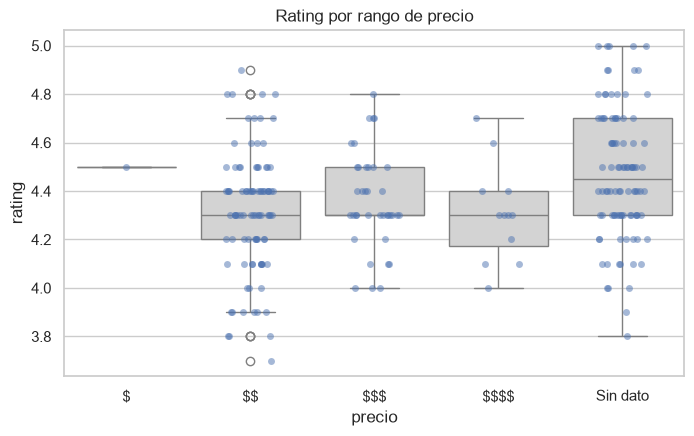

In [12]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df_yelp, x='precio', y='rating', order=ORDEN_PRECIO, color='lightgray')
sns.stripplot(data=df_yelp, x='precio', y='rating', order=ORDEN_PRECIO, alpha=0.5, jitter=0.2)   # un punto por restaurante
plt.title('Rating por rango de precio')
plt.show()

**Interpretación:**
- La oferta se concentra en el rango medio: `$$` (93 restaurantes), `$$$` (38) y `$$$$` (12). Solo 1 restaurante es `$`.
- Las categorías más frecuentes son de bares: *Cocktail Bars* (59), *New American* (44), *Italian* (26) y *Bars* (22). 103 de los 240 restaurantes (43%) tienen alguna categoría de bar.
- El rating es casi igual en todos los rangos de precio (4,3 a 4,4): pagar más no garantiza mejor calificación. Los `Sin dato` tienen un rating algo más alto (4,47), pero son un grupo heterogéneo. `$` tiene un solo dato, por eso el gráfico muestra cada punto.

### 5.3 ¿Los más populares son los mejor calificados?
Lo comprobamos con la correlación entre el rating y la cantidad de reseñas (en escala logarítmica, porque algunos locales tienen miles) y con el rating promedio de cada cuarto de restaurantes, del menos al más reseñado.

In [13]:
correlacion = df_yelp['rating'].corr(np.log(df_yelp['review_count']))
print(f'Correlación entre rating y cantidad de reseñas: {correlacion:.2f}')

Correlación entre rating y cantidad de reseñas: -0.38


In [14]:
# Dividimos los restaurantes en 4 grupos iguales según su cantidad de reseñas
df_yelp['grupo_resenas'] = pd.qcut(df_yelp['review_count'], 4, labels=['1 (pocas reseñas)', '2', '3', '4 (muchas reseñas)'])

df_yelp.groupby('grupo_resenas', observed=True)['rating'].agg(['mean', 'count']).round(2)

,mean,count
grupo_resenas,,
1 (pocas reseñas),4.53,60
2,4.39,60
3,4.34,60
4 (muchas reseñas),4.28,60


### 5.4 "Joyas ocultas": muy bien calificados pero poco conocidos
Son los restaurantes con rating de 4,6 o más y menos reseñas que la mediana: excelente nota y poca visibilidad, una oportunidad para que InsightReach los promocione. Exigimos al menos 30 reseñas para que la nota sea confiable (un 5,0 con 3 reseñas no dice mucho).

In [15]:
mediana_resenas = df_yelp['review_count'].median()
con_resenas_suficientes = df_yelp[df_yelp['review_count'] >= 30]      # al menos 30 reseñas
joyas = con_resenas_suficientes[(con_resenas_suficientes['rating'] >= 4.6) & (con_resenas_suficientes['review_count'] < mediana_resenas)]

print(f'Mediana de reseñas: {mediana_resenas:.0f}')
print(f"Restaurantes con 30 o más reseñas y rating de 4.6 o más: {(con_resenas_suficientes['rating'] >= 4.6).sum()}")
print(f'Joyas ocultas (además, con menos reseñas que la mediana): {len(joyas)}')

Mediana de reseñas: 234
Restaurantes con 30 o más reseñas y rating de 4.6 o más: 39
Joyas ocultas (además, con menos reseñas que la mediana): 24


In [16]:
joyas.sort_values(['rating', 'review_count'], ascending=[False, True]).head(10)[['nombre', 'rating', 'review_count', 'precio', 'categorias']]

,nombre,rating,review_count,precio,categorias
34,Cariño,4.9,43,Sin dato,"Latin American, Tacos, Latin American, Tacos"
39,Ila's,4.9,74,Sin dato,"Comfort Food, Salad, Cocktail Bars"
166,Suda’s Lebanese Cuisine,4.9,140,Sin dato,"Seafood, Mediterranean, Beer, Wine & Spirits"
75,Tepalcates,4.9,147,$$,"Tacos, Tacos"
82,Ox Bar & Hearth,4.8,48,Sin dato,"New American, Cocktail Bars, Breakfast & Brunch"
101,Omakase Shoji,4.8,53,Sin dato,"Japanese, Bars"
173,Avaspi,4.8,113,Sin dato,"Salad, Cocktail Bars, Mediterranean"
42,Dell Rooster,4.8,206,$$,"Latin American, Breakfast & Brunch, Sandwiches"
64,La Mom Kitchen,4.7,43,Sin dato,"Shanghainese, Szechuan"
41,Anatolia,4.7,46,Sin dato,"Mediterranean, Turkish, Cocktail Bars"


In [17]:
# ¿En qué rango de precio están las joyas ocultas?
joyas['precio'].value_counts()

precio
Sin dato    19
$$           4
$$$$         1
Name: count, dtype: int64

**Interpretación:**
- **Los más populares no son los mejor calificados.** La correlación entre rating y reseñas (en escala logarítmica) es de -0,38. Los restaurantes con menos reseñas tienen un rating promedio de 4,53 y los más reseñados, de 4,28. Una explicación posible es que los locales chicos tienen clientela fiel y los muy populares reciben opiniones más variadas, pero los datos no lo confirman.
- **Joyas ocultas:** de los 39 restaurantes con rating de 4,6 o más y al menos 30 reseñas, 24 tienen menos reseñas que la mediana (234). 19 de los 24 no informan precio (4 son `$$` y 1 `$$$$`), así que conviene verificarlo antes de promocionarlos.

## 6. Integrar Yelp con los clientes de Chicago

### 6.1 Cargar los clientes de Chicago ya limpios (Avance #1)
Repetimos la limpieza del Avance #1 (explicada paso a paso en la sección 4 de `Avance_EDA.ipynb`): filtrar la ciudad, pasar los errores a nulos, rellenar con la mediana y sacar los datos personales.

In [18]:
df_clientes = pd.read_csv(RUTA_DATA / 'base_datos_restaurantes_USA_v2.csv')
clientes = df_clientes[df_clientes['ciudad_residencia'] == CIUDAD].copy()

# Errores -> nulos
clientes.loc[(clientes['edad'] < 18) | (clientes['edad'] > 100), 'edad'] = np.nan
clientes.loc[clientes['frecuencia_visita'] < 0, 'frecuencia_visita'] = np.nan

# Nulos -> mediana
clientes['edad'] = clientes['edad'].fillna(clientes['edad'].median())
clientes['frecuencia_visita'] = clientes['frecuencia_visita'].fillna(clientes['frecuencia_visita'].median())
clientes['promedio_gasto_comida'] = clientes['promedio_gasto_comida'].fillna(clientes['promedio_gasto_comida'].median())
clientes['preferencias_alimenticias'] = clientes['preferencias_alimenticias'].fillna('Sin dato')

# Sin datos personales y con números enteros
clientes = clientes.drop(columns=['nombre', 'apellido', 'telefono_contacto', 'correo_electronico'])
clientes['edad'] = clientes['edad'].astype(int)
clientes['frecuencia_visita'] = clientes['frecuencia_visita'].astype(int)

print(f'Clientes de {CIUDAD}: {len(clientes):,} | Nulos restantes: {clientes.isnull().sum().sum()}')
clientes.head(3)

Clientes de Chicago: 5,384 | Nulos restantes: 0


,id_persona,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,tipo_de_pago_mas_usado,ingresos_mensuales
15,3456521319,61,Masculino,Chicago,Medio,2,23.02,Sí,Sí,Vegetariano,No,Efectivo,2838
21,2916502228,44,Femenino,Chicago,Bajo,3,5.07,No,Sí,Mariscos,No,App,1365
24,5736368501,54,Femenino,Chicago,Alto,5,34.35,No,Sí,Carnes,Sí,Tarjeta,7133


### 6.2 Encontrar una clave en común

Las dos tablas no comparten ningún identificador: la base de clientes no dice a qué restaurante va cada uno, así que no se puede cruzar fila a fila. La solución es cruzar por un atributo común, el tipo de comida. El cliente declara su `preferencias_alimenticias` y cada restaurante tiene `categorias`. Definimos 4 grupos que existen de los dos lados:

| Grupo | Preferencias del cliente | Categorías de Yelp afines |
|---|---|---|
| Carnes | Carnes | Steakhouses, Barbeque, Burgers, Hot Dogs, Chicken Wings, Chicken Shop, Butcher |
| Mariscos y pescado | Mariscos, Pescado | Seafood, Sushi Bars, Fish & Chips, Poke |
| Vegetariano/Vegano | Vegetariano, Vegano | Vegetarian, Vegan |
| Otro | Otro | Todo restaurante que no encaja en los anteriores |

Los clientes sin preferencia quedan en `Sin dato`. Un restaurante puede estar en más de un grupo (por ejemplo, una parrilla con mariscos).

**Restaurantes:** con `.str.contains()` buscamos esas categorías en el texto de cada restaurante. Cada columna nueva dice `True` o `False`.

In [19]:
df_yelp['carnes'] = df_yelp['aliases'].str.contains('steak|bbq|burgers|hotdog|chicken_wings|chickenshop|butcher')
df_yelp['mariscos_pescado'] = df_yelp['aliases'].str.contains('seafood|sushi|fishnchips|poke')
df_yelp['vegetariano_vegano'] = df_yelp['aliases'].str.contains('vegetarian|vegan')

# "Otro" = los que no encajan en ninguno de los tres grupos anteriores (~ significa "no")
df_yelp['otro'] = ~(df_yelp['carnes'] | df_yelp['mariscos_pescado'] | df_yelp['vegetariano_vegano'])

df_yelp[['carnes', 'mariscos_pescado', 'vegetariano_vegano', 'otro']].sum()

carnes                 32
mariscos_pescado       21
vegetariano_vegano      2
otro                  191
dtype: int64

**Clientes:** con `.map()` cambiamos cada preferencia por el nombre de su grupo usando un diccionario.

In [20]:
grupos = {'Carnes': 'Carnes', 'Mariscos': 'Mariscos y pescado', 'Pescado': 'Mariscos y pescado',
          'Vegetariano': 'Vegetariano/Vegano', 'Vegano': 'Vegetariano/Vegano', 'Otro': 'Otro', 'Sin dato': 'Sin dato'}

clientes['grupo_preferencia'] = clientes['preferencias_alimenticias'].map(grupos)
clientes['grupo_preferencia'].value_counts()

grupo_preferencia
Vegetariano/Vegano    1694
Carnes                1589
Mariscos y pescado    1242
Otro                   591
Sin dato               268
Name: count, dtype: int64

### 6.3 Tabla de oferta y demanda por grupo
Para cada grupo contamos cuántos clientes lo prefieren (demanda) y cuántos restaurantes de Yelp lo ofrecen (oferta).

In [21]:
nombres_grupos = ['Carnes', 'Mariscos y pescado', 'Vegetariano/Vegano', 'Otro']
columna_yelp = {'Carnes': 'carnes', 'Mariscos y pescado': 'mariscos_pescado',
                'Vegetariano/Vegano': 'vegetariano_vegano', 'Otro': 'otro'}

filas = []
for grupo in nombres_grupos:
    clientes_del_grupo = clientes[clientes['grupo_preferencia'] == grupo]
    restaurantes_del_grupo = df_yelp[df_yelp[columna_yelp[grupo]]]
    filas.append({'grupo_preferencia': grupo,
                  'n_clientes': len(clientes_del_grupo),
                  'gasto_prom': clientes_del_grupo['promedio_gasto_comida'].mean(),
                  'n_restaurantes': len(restaurantes_del_grupo),
                  'rating_prom': restaurantes_del_grupo['rating'].mean()})

oferta = pd.DataFrame(filas)
oferta['pct_clientes'] = oferta['n_clientes'] / len(clientes) * 100            # sobre todos los clientes
oferta['pct_restaurantes'] = oferta['n_restaurantes'] / len(df_yelp) * 100     # sobre todos los restaurantes
oferta['clientes_por_restaurante'] = oferta['n_clientes'] / oferta['n_restaurantes']
oferta['indice_cobertura'] = oferta['pct_restaurantes'] / oferta['pct_clientes']   # menor a 1 = oferta insuficiente
oferta.round(2)

,grupo_preferencia,n_clientes,gasto_prom,n_restaurantes,rating_prom,pct_clientes,pct_restaurantes,clientes_por_restaurante,indice_cobertura
0,Carnes,1589,24.94,32,4.31,29.51,13.33,49.66,0.45
1,Mariscos y pescado,1242,25.90,21,4.41,23.07,8.75,59.14,0.38
2,Vegetariano/Vegano,1694,25.82,2,4.10,31.46,0.83,847.00,0.03
3,Otro,591,24.71,191,4.40,10.98,79.58,3.09,7.25


**Interpretación:**
- **Vegetariano/Vegano:** 1.694 clientes (31,5%) y solo 2 restaurantes (0,8%). Son 847 clientes por restaurante y un índice de cobertura de 0,03.
- **Carnes** (índice 0,45) y **Mariscos y pescado** (0,38) están subatendidos, pero con 50 y 59 clientes por restaurante.
- **Otro** es el único grupo con oferta de sobra (índice 7,25 y 3 clientes por restaurante).
- El gasto por cliente es casi igual entre grupos (entre $24,7 y $25,9): la preferencia no cambia cuánto se gasta, solo dónde.
- Los 268 clientes `Sin dato` no tienen grupo para cruzar. Y 6 restaurantes (por ejemplo, Penumbra) cuentan en Carnes y en Mariscos y pescado a la vez, por eso los porcentajes de restaurantes suman un poco más de 100%.

### 6.4 Análisis de sensibilidad
La categoría vegetariana/vegana de Yelp es muy chica, así que verificamos si el hallazgo cambia con una definición más amplia que sume ensaladas, falafel y opciones sin gluten.

In [22]:
vegetariano_amplio = df_yelp['aliases'].str.contains('vegetarian|vegan|salad|falafel|gluten_free')
clientes_veg = (clientes['grupo_preferencia'] == 'Vegetariano/Vegano').sum()

print(f'Clientes vegetarianos/veganos: {clientes_veg:,} ({clientes_veg / len(clientes):.1%})')
print(f"Restaurantes (definición estricta): {df_yelp['vegetariano_vegano'].sum()} ({df_yelp['vegetariano_vegano'].mean():.1%})")
print(f'Restaurantes (definición amplia):   {vegetariano_amplio.sum()} ({vegetariano_amplio.mean():.1%})')

Clientes vegetarianos/veganos: 1,694 (31.5%)
Restaurantes (definición estricta): 2 (0.8%)
Restaurantes (definición amplia):   9 (3.8%)


**Interpretación:** aun con la definición amplia, la oferta llega a solo 9 restaurantes (3,8%) frente a un 31,5% de clientes. El desajuste se mantiene con las dos definiciones, así que la conclusión es robusta.

### 6.5 Integración: sumar la información de Yelp a cada cliente

Con `pd.merge` (*left join* por `grupo_preferencia`) le agregamos a cada cliente las métricas de la oferta de su preferencia. *Left join* significa que se conservan todos los clientes y se les pegan los datos de Yelp cuando existen: los `Sin dato` quedan con esas columnas vacías.

In [23]:
yelp_por_grupo = oferta[['grupo_preferencia', 'n_restaurantes', 'rating_prom', 'clientes_por_restaurante', 'indice_cobertura']]

base_unificada = pd.merge(clientes, yelp_por_grupo, on='grupo_preferencia', how='left')

print(f'Antes: {len(clientes):,} clientes | Después del merge: {len(base_unificada):,} clientes (no se pierde ni se duplica ninguno)')
base_unificada[['id_persona', 'preferencias_alimenticias', 'grupo_preferencia', 'n_restaurantes',
                'rating_prom', 'clientes_por_restaurante', 'indice_cobertura']].sample(6, random_state=1)

Antes: 5,384 clientes | Después del merge: 5,384 clientes (no se pierde ni se duplica ninguno)


,id_persona,preferencias_alimenticias,grupo_preferencia,n_restaurantes,rating_prom,clientes_por_restaurante,indice_cobertura
1548,5182110973,Sin dato,Sin dato,NaN,NaN,NaN,NaN
3960,8766884198,Vegetariano,Vegetariano/Vegano,2.0,4.100000,847.000000,0.026486
4221,2826423231,Otro,Otro,191.0,4.397382,3.094241,7.250028
1626,2476811694,Vegetariano,Vegetariano/Vegano,2.0,4.100000,847.000000,0.026486
3485,7846389041,Mariscos,Mariscos y pescado,21.0,4.409524,59.142857,0.379308
4021,4973774025,Otro,Otro,191.0,4.397382,3.094241,7.250028


### 6.6 Guardar la base unificada en CSV
Guardamos la base que une a cada cliente con la información de Yelp de su preferencia.

In [24]:
base_unificada.to_csv(RUTA_DATA / 'base_unificada_chicago.csv', index=False)
print('Guardado: data/base_unificada_chicago.csv')

Guardado: data/base_unificada_chicago.csv


### 6.7 Visualización: clientes por cada restaurante afín

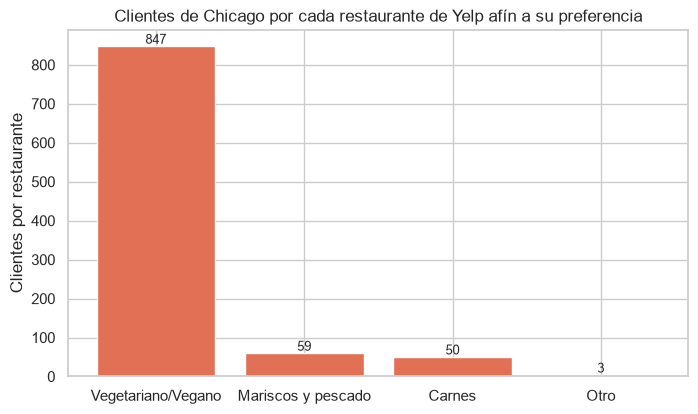

In [25]:
grafico = oferta.sort_values('clientes_por_restaurante', ascending=False)

plt.figure(figsize=(8, 4.5))
barras = plt.bar(grafico['grupo_preferencia'], grafico['clientes_por_restaurante'], color='#e17055')
plt.bar_label(barras, fmt='%.0f', fontsize=9)
plt.title('Clientes de Chicago por cada restaurante de Yelp afín a su preferencia')
plt.ylabel('Clientes por restaurante')
plt.show()

**Interpretación:** la base unificada conserva los mismos 5.384 clientes y cada uno lleva la información de mercado de su preferencia: cuántos restaurantes afines hay, su rating promedio y cuántos clientes compiten por cada uno. La sección 8 de `Avance_EDA.ipynb` (Avance #3) parte de esta base. Queda guardada en `data/base_unificada_chicago.csv`.

## Limitaciones
- La API devuelve los resultados más relevantes, no todos los restaurantes: la muestra (240 de 7.900) favorece a los locales populares.
- Las categorías describen el tipo de negocio, no el menú, así que el cruce con las preferencias es una aproximación.
- La conexión en vivo requiere una clave propia en el archivo `.env`; sin ella se lee el CSV guardado con una respuesta real de la API.